<a href="https://colab.research.google.com/github/Hafsahshaikh/AIML_Projects_and_Labs-IIITH/blob/main/AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=0beb4bfe4bd05d85cd67ad96a2f51248505b2ac72ae7e87223d143c2e3b814b2
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
topic1 = 'Giraffe'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

# Use French topic names when querying French Wikipedia
fr1 = wikipedia.page('Giraffa').content
fr2 = wikipedia.page('Éléphant').content

This is what the text looks like:

In [ ]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. \nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [ ]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [ ]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [ ]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [ ]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

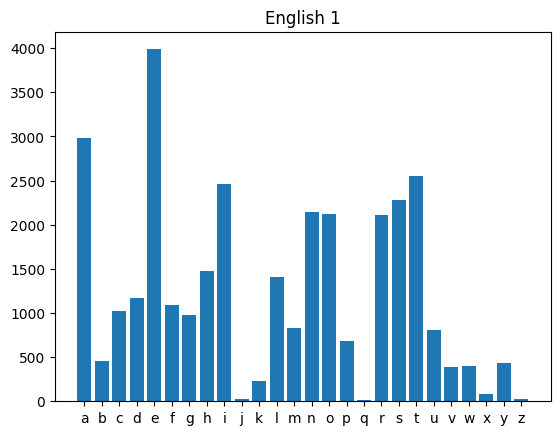

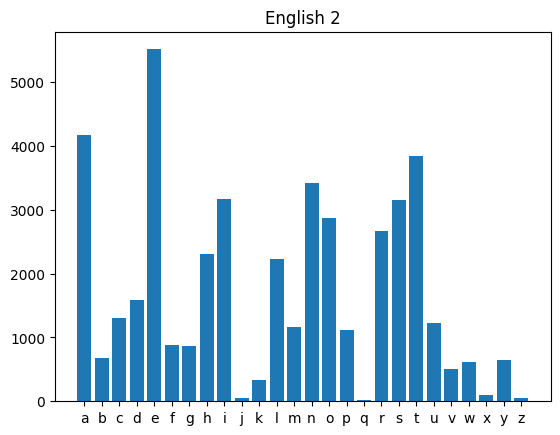

In [ ]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

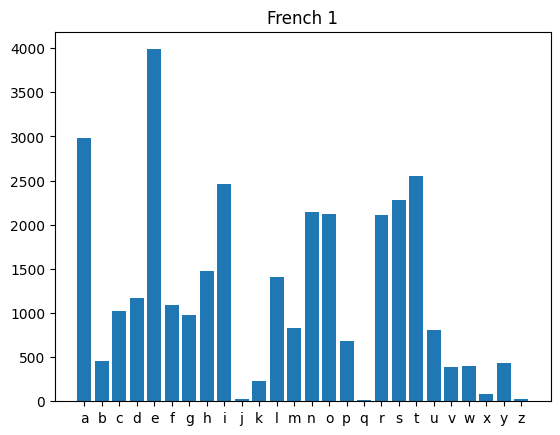

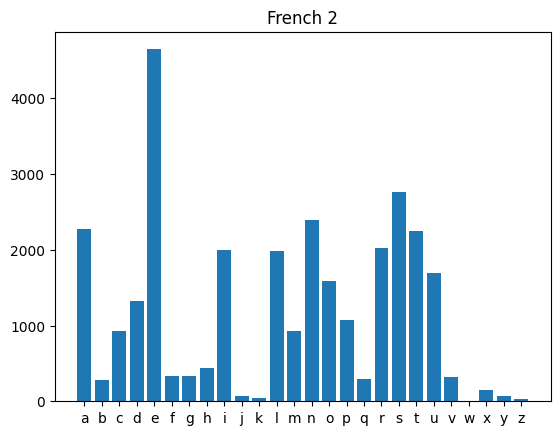

In [ ]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_eng1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

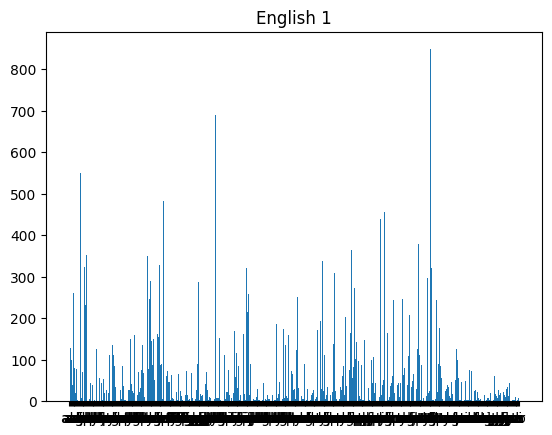

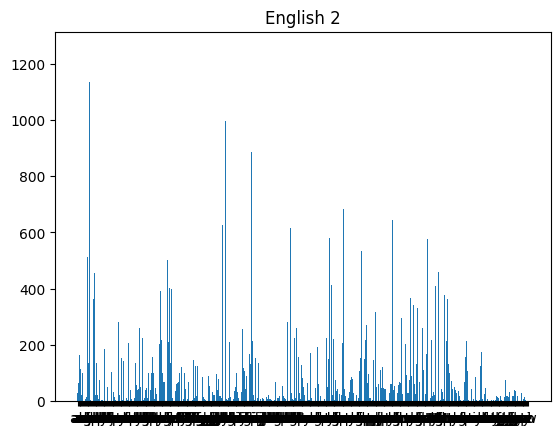

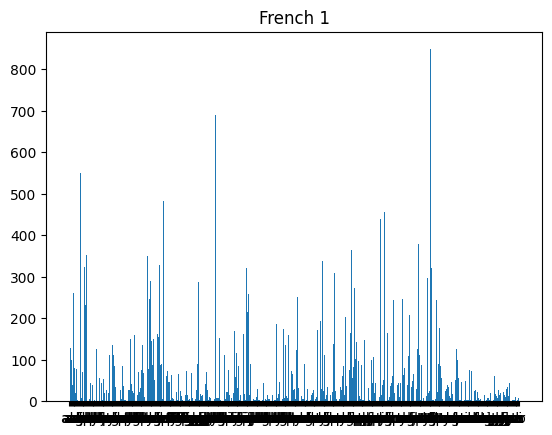

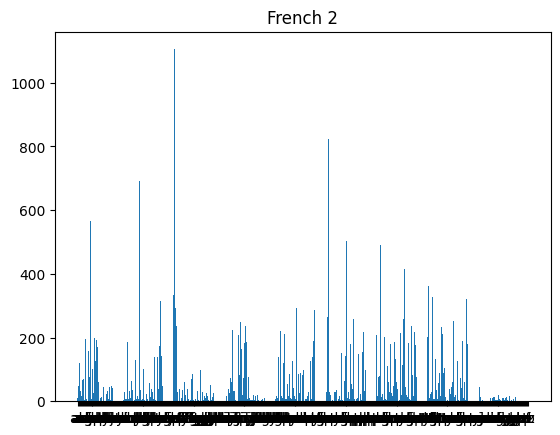

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2)) # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_eng1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [ ]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

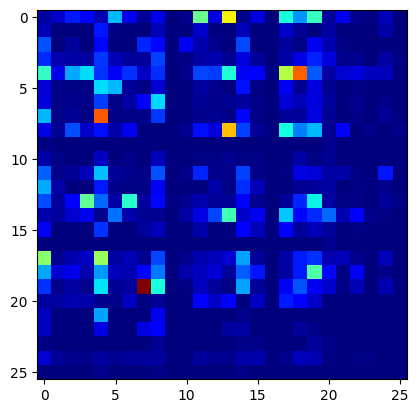

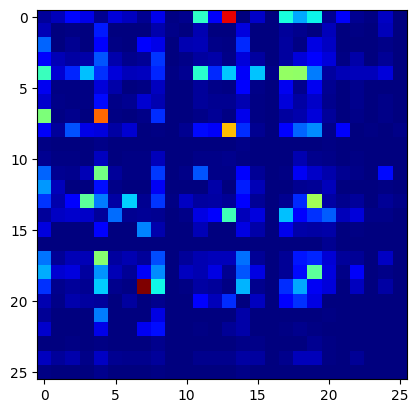

In [ ]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

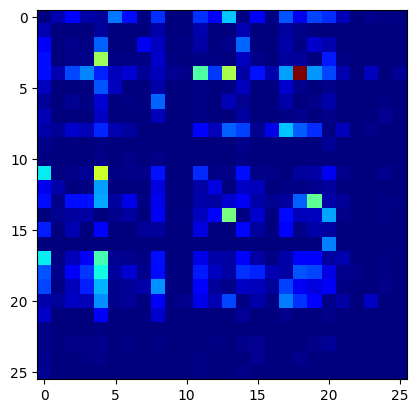

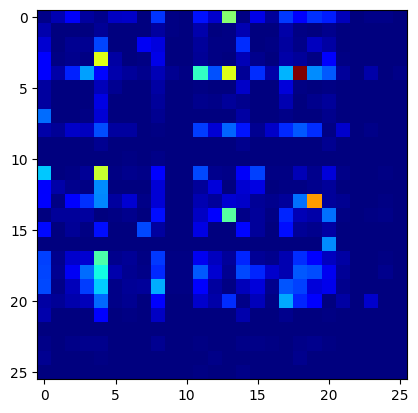

In [ ]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [ ]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [ ]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 796.0
('l', 'e') : 478.0
('e', 'n') : 444.0
('d', 'e') : 430.0
('o', 'n') : 392.0
('n', 't') : 372.0
('e', 'l') : 355.0
('r', 'e') : 346.0
('s', 'e') : 298.0
('r', 'a') : 287.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

**1. Trying with different languages( Spanish & German )**

**Answer:**
The below result shows that unigram and bigram frequencies capture structural patterns of languages. While bigram distributions remain similar across different topics in the same language, they vary significantly across languages.

Therefore, n-gram frequencies are useful features for language identification but less effective for distinguishing topics.

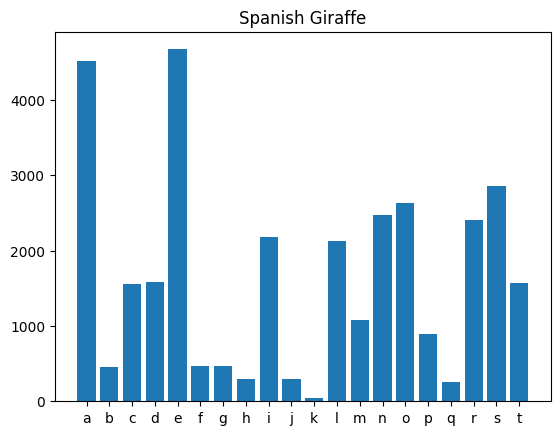

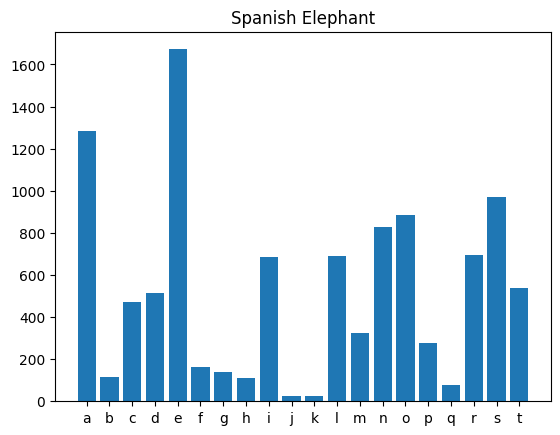

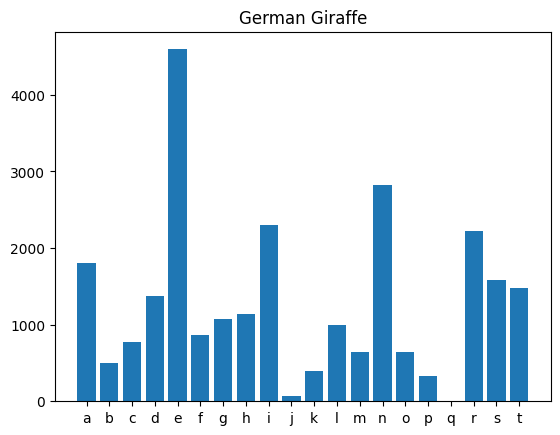

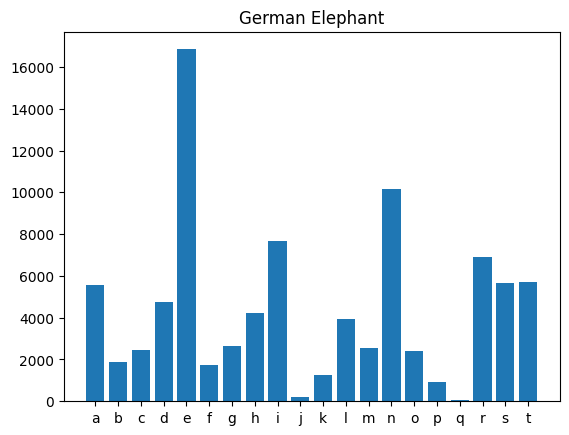

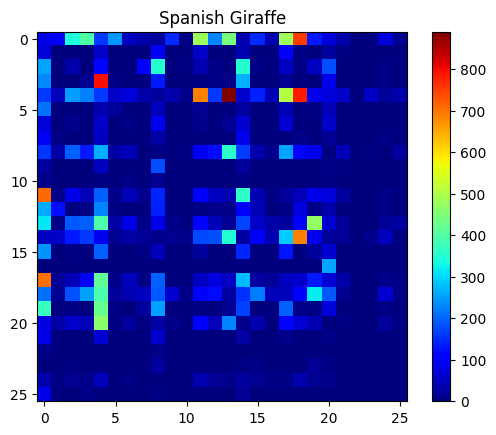

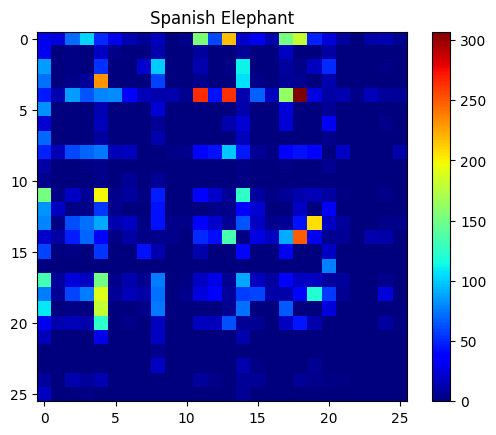

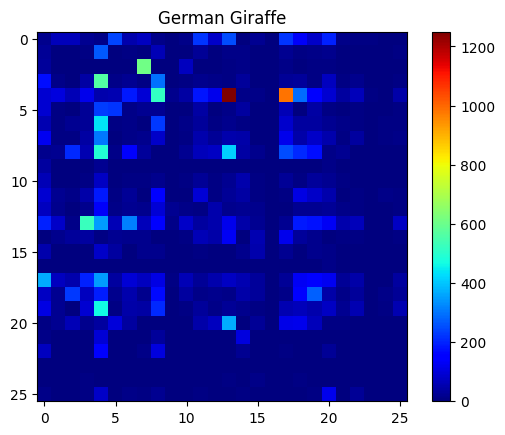

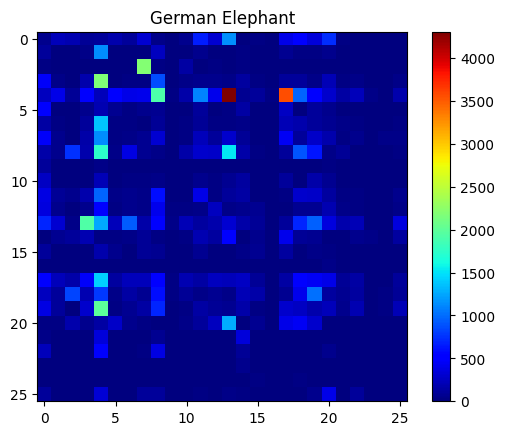


Spanish Giraffe:
('e', 'n') : 890.0
('d', 'e') : 794.0
('e', 's') : 785.0
('a', 's') : 752.0
('l', 'a') : 711.0
('r', 'a') : 703.0
('o', 's') : 688.0
('e', 'l') : 687.0
('e', 'r') : 507.0
('a', 'r') : 482.0

Spanish Elephant:
('e', 's') : 307.0
('e', 'l') : 265.0
('e', 'n') : 263.0
('o', 's') : 249.0
('d', 'e') : 231.0
('a', 'n') : 216.0
('n', 't') : 207.0
('l', 'e') : 198.0
('s', 'e') : 190.0
('t', 'e') : 180.0

German Giraffe:
('e', 'n') : 1250.0
('e', 'r') : 984.0
('c', 'h') : 609.0
('d', 'e') : 565.0
('n', 'd') : 525.0
('e', 'i') : 513.0
('i', 'e') : 491.0
('t', 'e') : 465.0
('g', 'e') : 439.0
('i', 'n') : 414.0

German Elephant:
('e', 'n') : 4306.0
('e', 'r') : 3558.0
('c', 'h') : 2194.0
('d', 'e') : 2170.0
('t', 'e') : 1991.0
('n', 'd') : 1933.0
('e', 'i') : 1901.0
('i', 'e') : 1745.0
('i', 'n') : 1514.0
('r', 'e') : 1417.0


In [ ]:
!pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re

# Topics
topic1 = 'Giraffe'
topic2 = 'Elephant'

# Spanish
wikipedia.set_lang('es')
sp1 = wikipedia.page('Jirafa').content
sp2 = wikipedia.page('Elefante').content

# German
wikipedia.set_lang('de')
de1 = wikipedia.page('Giraffe', auto_suggest=False).content # Changed from 'Giraffen' to 'Giraffe', and added auto_suggest=False
de2 = wikipedia.page('Elefant').content

# Text Cleaning
def cleanup(text):
    text = text.lower()
    text = re.sub('[^a-z]+','',text)
    return text

sp1 = cleanup(sp1)
sp2 = cleanup(sp2)
de1 = cleanup(de1)
de2 = cleanup(de2)


def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st

def key2string(keys):
    return [tuple2string(i) for i in keys]

def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)
    zipped_sorted = sorted(combined, key=lambda x: x[0])
    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys[:20], values[:20])   # show first 20 for readability

# Unigram Histograms

# Spanish
unigram_sp1 = Counter(ngrams(sp1,1))
plothistogram(unigram_sp1)
plt.title('Spanish Giraffe')
plt.show()

unigram_sp2 = Counter(ngrams(sp2,1))
plothistogram(unigram_sp2)
plt.title('Spanish Elephant')
plt.show()

# German
unigram_de1 = Counter(ngrams(de1,1))
plothistogram(unigram_de1)
plt.title('German Giraffe')
plt.show()

unigram_de2 = Counter(ngrams(de2,1))
plothistogram(unigram_de2)
plt.title('German Elephant')
plt.show()

# Bigram Histograms

bigram_sp1 = Counter(ngrams(sp1,2))
bigram_sp2 = Counter(ngrams(sp2,2))

bigram_de1 = Counter(ngrams(de1,2))
bigram_de2 = Counter(ngrams(de2,2))

# Bigram Heatmap

def plotbihistogram(ngram):
    freq = np.zeros((26,26))

    for ii in range(26):
        for jj in range(26):
            freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]

    plt.imshow(freq, cmap='jet')
    plt.colorbar()
    return freq

# Spanish
bisp1 = plotbihistogram(bigram_sp1)
plt.title("Spanish Giraffe")
plt.show()

bisp2 = plotbihistogram(bigram_sp2)
plt.title("Spanish Elephant")
plt.show()

# German
bide1 = plotbihistogram(bigram_de1)
plt.title("German Giraffe")
plt.show()

bide2 = plotbihistogram(bigram_de2)
plt.title("German Elephant")
plt.show()

# Show Top Bigrams

def ind2tup(ind):
    ind = int(ind)
    i = int(ind/26)
    j = int(ind%26)
    return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
    f = bifreq.flatten()
    arg = np.argsort(-f)

    for ii in range(n):
        print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

print("\nSpanish Giraffe:")
ShowTopN(bisp1)

print("\nSpanish Elephant:")
ShowTopN(bisp2)

print("\nGerman Giraffe:")
ShowTopN(bide1)

print("\nGerman Elephant:")
ShowTopN(bide2)


**2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?**

**Answer:**

Using different types of topic and source other than wikipedia

Topic 1: Space Exploration

Topic 2: Cooking

Source: Project Gutenberg (not Wikipedia)

Although the topics (space exploration and cooking) are very different, the bigram distributions are similar because they reflect the structure of the English language rather than topic-specific vocabulary.

startoftheprojectgutenbergebookthetimemachineaninventionbyhgwellscontentsiintroductioniithemachineiiithetimetravellerreturnsivtimetravellingvinthegoldenagevithesunsetofmankindviiasuddenshockviiiexplanationixthemorlocksxwhennightcamexithepalaceofgreenporcelainxiiinthedarknessxiiithetrapofthewhitesphinxxivthefurthervisionxvthetimetravellersreturnxviafterthestoryepilogueiintroductionthetimetravellerforsoitwillbeconvenienttospeakofhimwasexpoundingareconditemattertoushispalegreyeyesshoneandtwinkledan


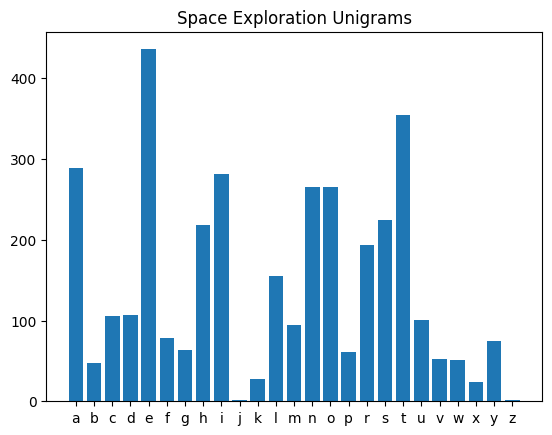

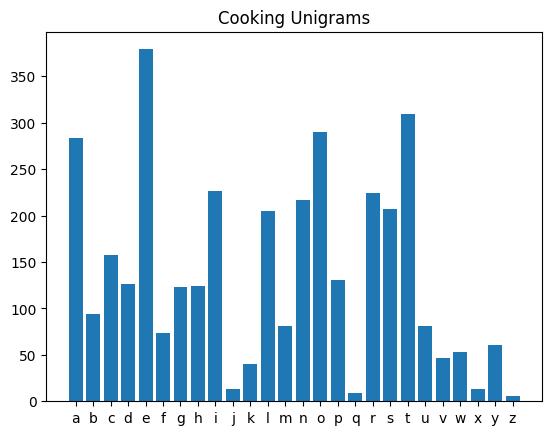

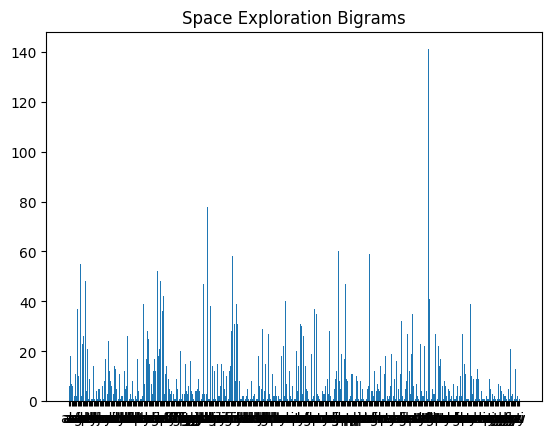

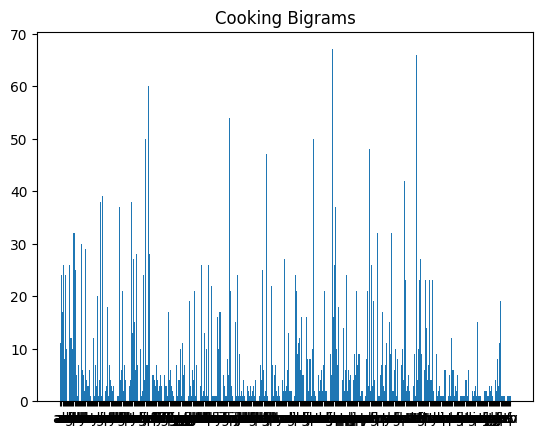

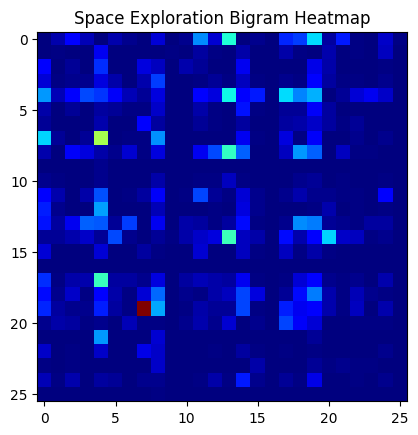

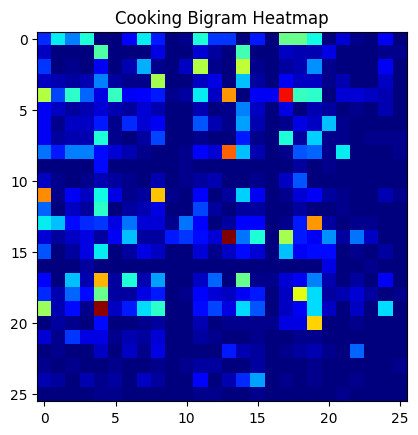


Space Exploration Text:
('t', 'h') : 141.0
('h', 'e') : 78.0
('o', 'n') : 60.0
('r', 'e') : 59.0
('i', 'n') : 58.0
('a', 'n') : 55.0
('e', 'n') : 52.0
('a', 't') : 48.0
('e', 'r') : 48.0
('o', 'u') : 47.0

Cooking Text:
('o', 'n') : 67.0
('t', 'e') : 66.0
('e', 'r') : 60.0
('i', 'n') : 54.0
('l', 'a') : 51.0
('e', 'n') : 50.0
('n', 't') : 50.0
('r', 'e') : 48.0
('l', 'i') : 47.0
('u', 't') : 46.0


In [ ]:
import requests
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re

# Download texts (not Wikipedia)

url1 = "https://www.gutenberg.org/files/35/35-0.txt"     # Space / science fiction text
url2 = "https://www.gutenberg.org/files/419/419-0.txt"   # Cooking / food related text

space = requests.get(url1).text
cooking = requests.get(url2).text

# Clean the text

def cleanup(text):
    text = text.lower()
    text = re.sub('[^a-z]+','',text)
    return text

space = cleanup(space)
cooking = cleanup(cooking)

print(space[:500])

# Make texts same length
min_len = min(len(space), len(cooking))
space = space[:min_len]
cooking = cooking[:min_len]

# convert tuple of characters to string

def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st

# convert tuple keys to list of strings

def key2string(keys):
    return [tuple2string(i) for i in keys]

# histogram

def plothistogram(ngram):

    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)
    zipped_sorted = sorted(combined, key=lambda x: x[0])

    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)

# Unigrams

unigram_space = Counter(ngrams(space,1))
plothistogram(unigram_space)
plt.title('Space Exploration Unigrams')
plt.show()

unigram_cooking = Counter(ngrams(cooking,1))
plothistogram(unigram_cooking)
plt.title('Cooking Unigrams')
plt.show()

# Bigrams

bigram_space = Counter(ngrams(space,2))
plothistogram(bigram_space)
plt.title('Space Exploration Bigrams')
plt.show()

bigram_cooking = Counter(ngrams(cooking,2))
plothistogram(bigram_cooking)
plt.title('Cooking Bigrams')
plt.show()

# Bigram heatmap

def plotbihistogram(ngram):

    freq = np.zeros((26,26))

    for ii in range(26):
        for jj in range(26):

            freq[ii,jj] = ngram[(chr(ord('a')+ii),
                                chr(ord('a')+jj))]

    plt.imshow(freq, cmap='jet')
    return freq


bispace = plotbihistogram(bigram_space)
plt.title("Space Exploration Bigram Heatmap")
plt.show()

bicooking = plotbihistogram(bigram_cooking)
plt.title("Cooking Bigram Heatmap")
plt.show()

# Show Top Bigrams

def ind2tup(ind):
    ind = int(ind)
    i = int(ind/26)
    j = int(ind%26)
    return (chr(ord('a')+i), chr(ord('a')+j))


def ShowTopN(bifreq, n=10):

    f = bifreq.flatten()
    arg = np.argsort(-f)

    for ii in range(n):
        print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')


print('\nSpace Exploration Text:')
ShowTopN(bispace)

print('\nCooking Text:')
ShowTopN(bicooking)

**3. How can we use and visualize trigrams and higher n-grams?**

**Answer:**

To use and visualize trigrams and higher n-grams, we extend the same idea used for unigram and bigrams.

Trigrams = sequence of 3 characters

4-grams = sequence of 4 characters

n-grams = sequence of n characters

**TRIGRAMS**

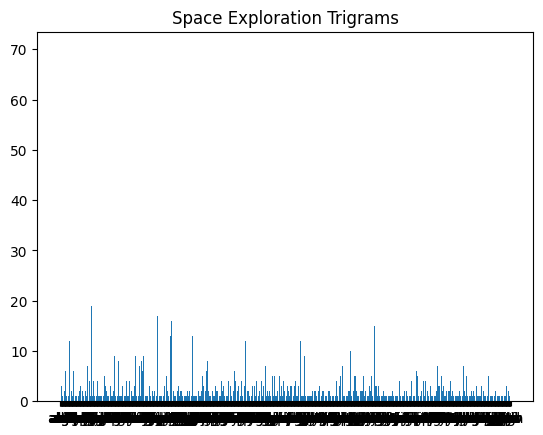

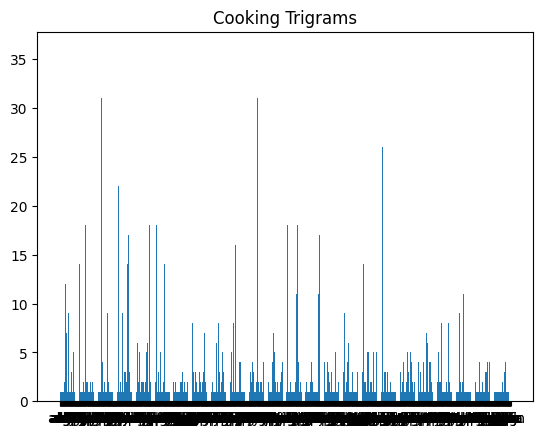


Top Space Trigrams:
('t', 'h', 'e') : 70
('i', 'o', 'n') : 27
('t', 'h', 'a') : 24
('i', 'm', 'e') : 23
('t', 'h', 'i') : 21
('a', 'n', 'd') : 20
('a', 'v', 'e') : 19
('h', 'a', 't') : 19
('n', 's', 'i') : 17
('i', 'n', 'g') : 17

Top Cooking Trigrams:
('t', 'e', 'n') : 36
('c', 'l', 'a') : 31
('l', 'a', 's') : 31
('a', 's', 's') : 31
('c', 'o', 'n') : 30
('o', 'n', 't') : 27
('h', 'r', 'e') : 26
('r', 'e', 'f') : 26
('d', 'i', 'v') : 22
('a', 'h', 'r') : 22


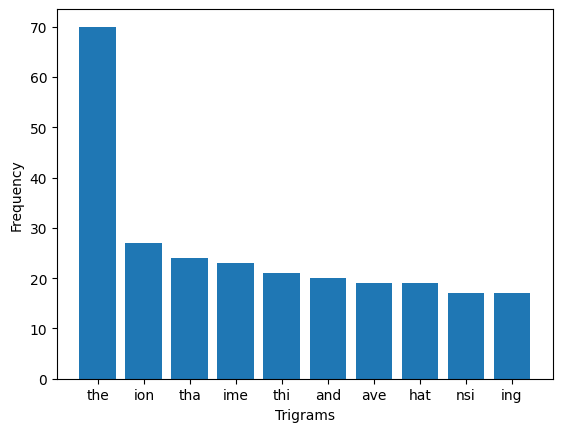

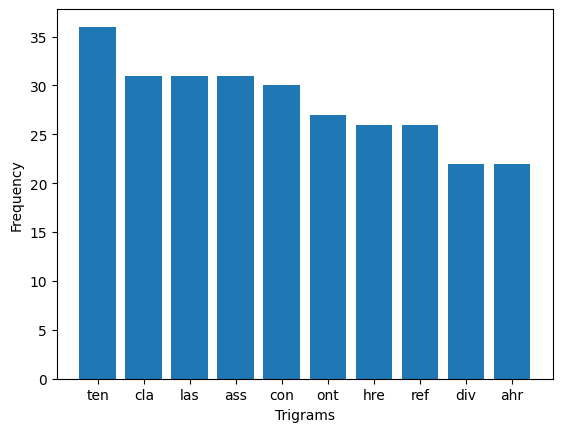

In [ ]:
trigram_space = Counter(ngrams(space,3))
trigram_cooking = Counter(ngrams(cooking,3))

plothistogram(trigram_space)
plt.title('Space Exploration Trigrams')
plt.show()

plothistogram(trigram_cooking)
plt.title('Cooking Trigrams')
plt.show()

def ShowTopTrigrams(trigram, n=10):

    for key, value in trigram.most_common(n):
        print(key, ":", value)

print("\nTop Space Trigrams:")
ShowTopTrigrams(trigram_space)

print("\nTop Cooking Trigrams:")
ShowTopTrigrams(trigram_cooking)

def plot_top_trigrams(trigram):

    labels = []
    values = []

    for key, value in trigram.most_common(10):
        labels.append(''.join(key))
        values.append(value)

    plt.bar(labels, values)
    plt.xlabel("Trigrams")
    plt.ylabel("Frequency")
    plt.show()

plot_top_trigrams(trigram_space)
plot_top_trigrams(trigram_cooking)

**N GRAM**


Top 4-grams in Space Exploration Text:
('s', 'i', 'o', 'n') 16
('t', 'h', 'a', 't') 16
('e', 'n', 's', 'i') 15
('t', 'h', 'e', 'r') 13
('n', 's', 'i', 'o') 13
('h', 'a', 'v', 'e') 12
('d', 'i', 'm', 'e') 12
('i', 'm', 'e', 'n') 12
('m', 'e', 'n', 's') 12
('o', 'f', 't', 'h') 11


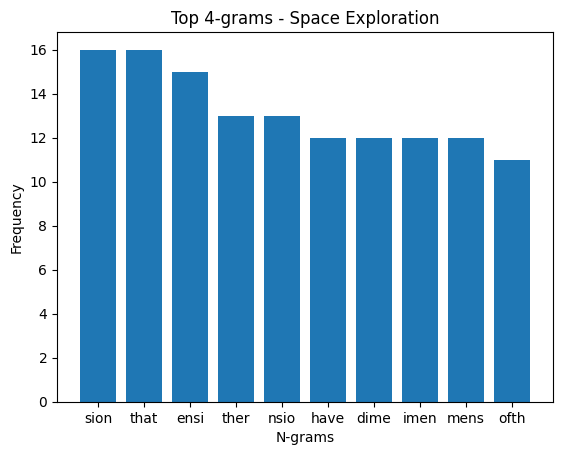


Top 4-grams in Cooking Text:
('c', 'l', 'a', 's') 31
('l', 'a', 's', 's') 31
('h', 'r', 'e', 'f') 26
('c', 'o', 'n', 't') 26
('a', 'h', 'r', 'e') 22
('g', 'u', 't', 'e') 18
('u', 't', 'e', 'n') 18
('t', 'e', 'n', 'b') 18
('e', 'n', 'b', 'e') 18
('n', 'b', 'e', 'r') 18


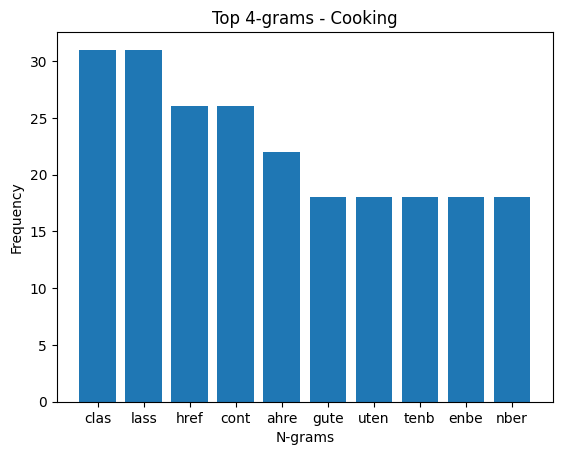

In [ ]:
def plot_ngram(ngram_counter, title):

    labels = []
    values = []

    for key,value in ngram_counter.most_common(10):
        labels.append(tuple2string(key))
        values.append(value)

    plt.bar(labels,values)
    plt.title(title)
    plt.xlabel("N-grams")
    plt.ylabel("Frequency")
    plt.show()


# create 4-grams for both texts
fourgrams = {
    "Space Exploration": Counter(ngrams(space,4)),
    "Cooking": Counter(ngrams(cooking,4))
}

# single loop for printing and plotting
for topic, fourgram in fourgrams.items():

    print(f"\nTop 4-grams in {topic} Text:")

    for key,value in fourgram.most_common(10):
        print(key,value)

    plot_ngram(fourgram,f"Top 4-grams - {topic}")

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [ ]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Extract a subset of the data for our experiment:

In [ ]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

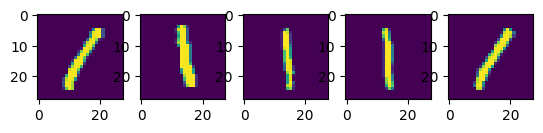

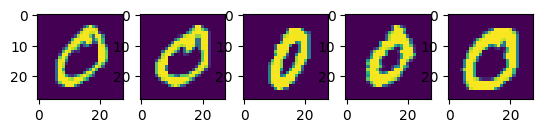

In [ ]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no1[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [ ]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

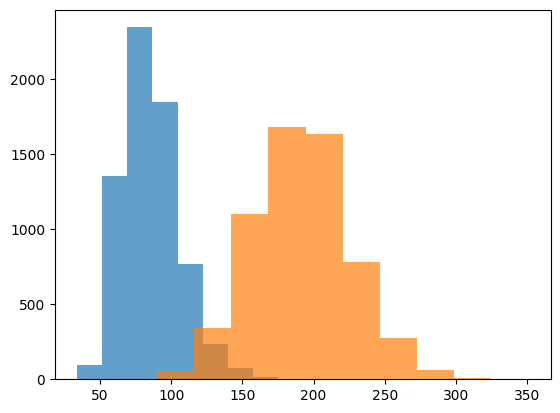

In [ ]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [ ]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

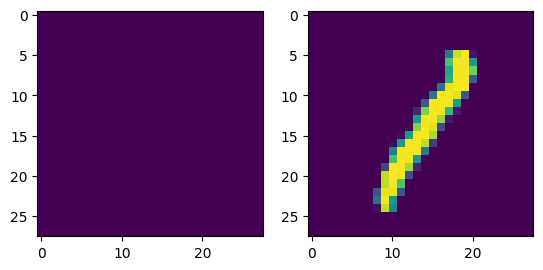

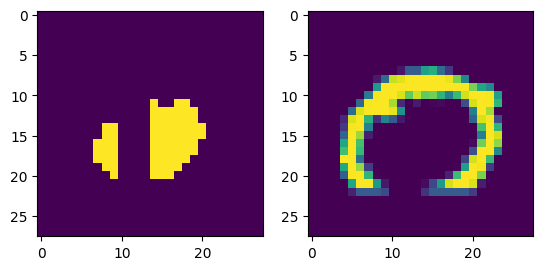

In [ ]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

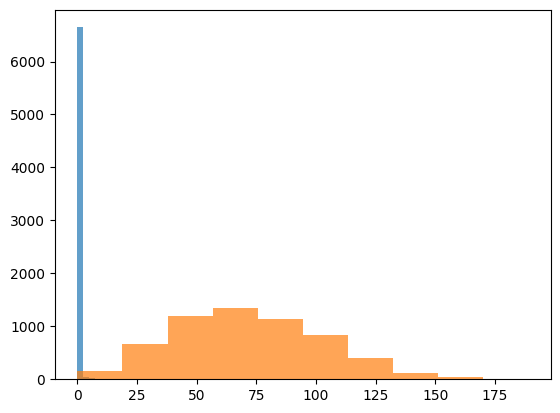

In [ ]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7);
plt.hist(hole0, alpha=0.7);

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [ ]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

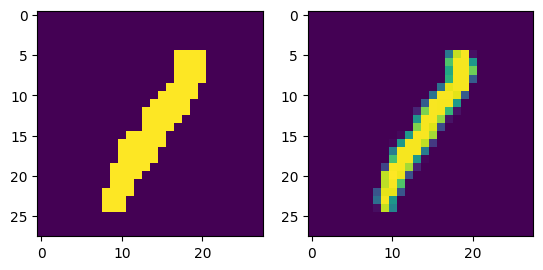

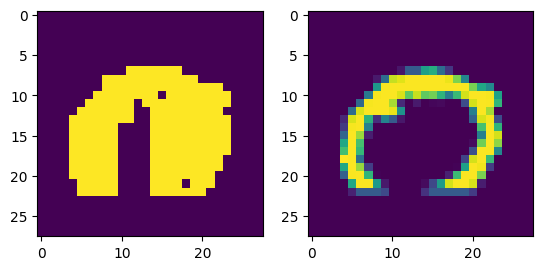

In [ ]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

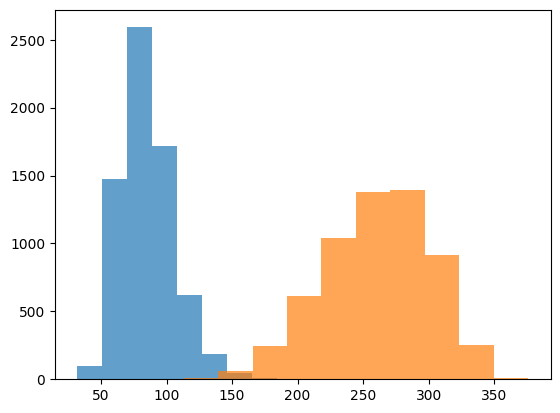

In [ ]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7);
plt.hist(hull0, alpha=0.7);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [ ]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

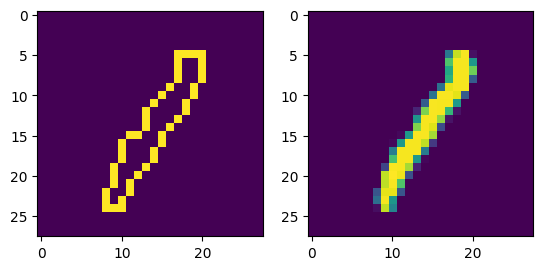

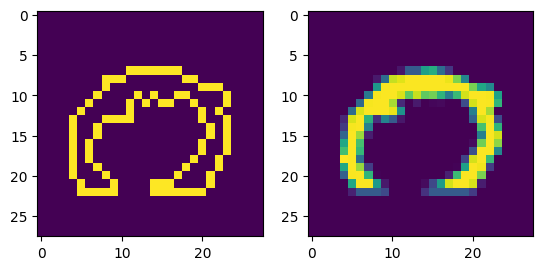

In [ ]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

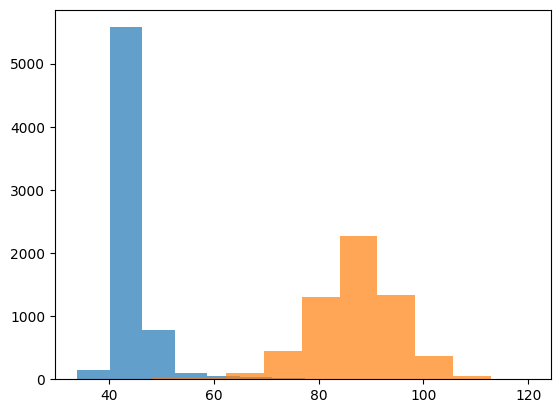

In [ ]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7);
plt.hist(bound0, alpha=0.7);

What will happen if we plot two features together?

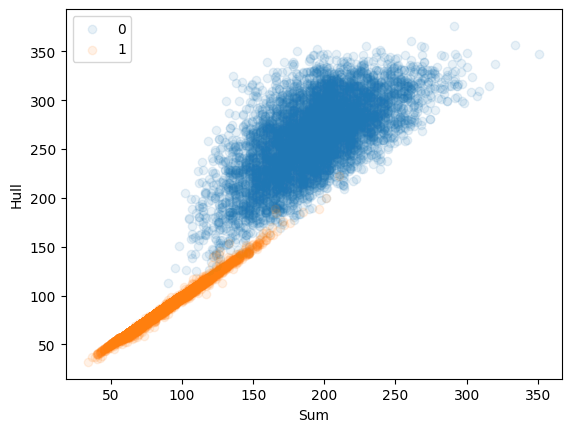

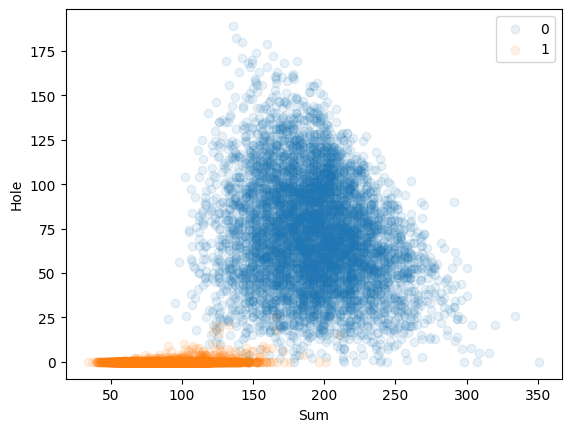

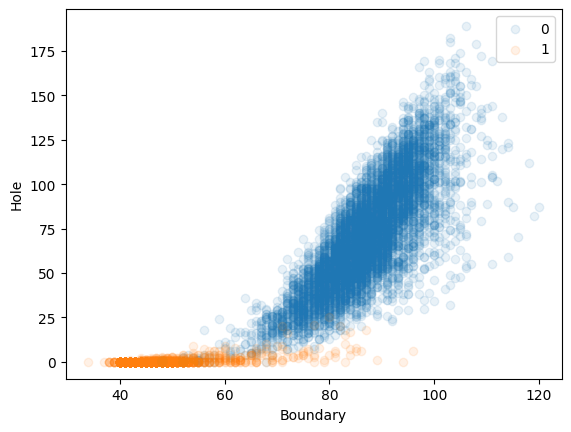

In [ ]:
# Sum and hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

Now let us try plotting 3 features together.

In [ ]:
cl1 = ['class 1']*len(sum1)
cl0 = ['class 0']*len(sum0)
df = pd.DataFrame(list(zip(np.concatenate((hole0, hole0)), np.concatenate((sum1,sum0)),
                           np.concatenate((bound1,bound0)), np.concatenate((cl1, cl0)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?

**A**. The best feature combination is the one that clearly separates the classes in the feature space. For digits 0 and 1, features like hole pixels and boundary pixels work well because digit 0 contains holes while digit 1 does not.

2. How would you test or visualize four or more features?

**A**. When there are four or more features, we can use pairwise scatter plots, 3D plots, or dimensionality reduction techniques such as PCA to visualize the data.

3. Can you come up with your own features?

**A**. Additional features such as digit width, height and stroke thickness can be used.

4. Will these features work for different classes other than 0 and 1?

**A**. These features may help distinguish some digits (like 0, 6, and 8 due to holes), but may not work well for digits with similar shapes.

5. What will happen if we take more that two classes at a time?

**A** .When more classes are included, the feature space becomes more complex and crowded, requiring more advanced features or machine learning models.